# 1. Data Inspection

**Project:** Heart Failure Prediction — Data Preparation for Classification

**Prepared by:** Nicole Mauti,Data Science Intern, AnalystLab Africa Consulting 

**Stage:** Week 2 — Data Inspection

---

**Purpose of this notebook:**The primary objective of this project is to prepare the Heart Failure Prediction dataset for a supervised machine learning model that predicts the presence of heart disease based on patient characteristics. The focus at this stage is to clean, transform, and engineer the data by handling missing values and outliers, encoding categorical variables, addressing redundant features, and scaling numerical variables where appropriate, creating a reliable dataset for subsequent model development and evaluation.


In [139]:
#import libraries
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display and style settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


**1.1 Loading the Dataset**

In [141]:
df = pd.read_csv('heart.csv')
df_raw = df.copy()
print("Dataset loaded successfully.")

Dataset loaded successfully.


**1.2 Dataset Insppection Overview**

In [143]:
print (df.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [144]:
#first 10 rows
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [145]:
n_rows, n_cols = df.shape
print(f"Number of rows (patients): {n_rows}")
print(f"Number of columns (variables): {n_cols}")


Number of rows (patients): 918
Number of columns (variables): 12


**Interpretation:** The dataset contains **918 patient records** across **12 variables** (11 potential predictors plus the target `HeartDisease`). 

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [148]:
print ("Data types per column:")
print (df.dtypes)

Data types per column:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [149]:
# Continuous variables
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Categorical variables 
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG',
                     'ExerciseAngina', 'ST_Slope']

print("Numerical variables:", numerical_cols)
print()
print("Categorical variables:", categorical_cols)
print()


Numerical variables: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

Categorical variables: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']



In [150]:
#unique values per column
print("Unique value counts per column (helps confirm categorical vs numerical):")
print(df.nunique().sort_values())


Unique value counts per column (helps confirm categorical vs numerical):
Sex                 2
FastingBS           2
ExerciseAngina      2
HeartDisease        2
RestingECG          3
ST_Slope            3
ChestPainType       4
Age                50
Oldpeak            53
RestingBP          67
MaxHR             119
Cholesterol       222
dtype: int64


In [151]:
#checking for missing values 
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
})

print(missing_summary)
print()
print(f"Total missing values in dataset: {missing_counts.sum()}")


                missing_count  missing_pct
Age                         0          0.0
Sex                         0          0.0
ChestPainType               0          0.0
RestingBP                   0          0.0
Cholesterol                 0          0.0
FastingBS                   0          0.0
RestingECG                  0          0.0
MaxHR                       0          0.0
ExerciseAngina              0          0.0
Oldpeak                     0          0.0
ST_Slope                    0          0.0
HeartDisease                0          0.0

Total missing values in dataset: 0


**Interpretation:** There are **zero standard (NaN) missing values** in any of the 12 columns. However, "no missing values" in the technical sense does not necessarily mean the data is fully clean. Some columns may contain placeholder values (such as `0`) that represent missing or unrecorded measurements in disguise. We investigate this specifically for the physiological columns below.


In [153]:
zero_restingbp = (df['RestingBP'] == 0).sum()
zero_cholesterol = (df['Cholesterol'] == 0).sum()

print(f"Records with RestingBP == 0: {zero_restingbp} ({zero_restingbp/len(df)*100:.2f}%)")
print(f"Records with Cholesterol == 0: {zero_cholesterol} ({zero_cholesterol/len(df)*100:.2f}%)")

Records with RestingBP == 0: 1 (0.11%)
Records with Cholesterol == 0: 172 (18.74%)


**Interpretation:** While `isnull().sum()` reports zero missing values, we find **1 record with `RestingBP == 0`** and **172 records (18.74%) with `Cholesterol == 0`**. A resting blood pressure or serum cholesterol reading of exactly zero is not physiologically possible in a living patient — these are very likely **disguised missing values** (unrecorded measurements coded as 0) rather than genuine clinical readings. This is a significant data-quality finding: nearly 1 in 5 patients has an effectively missing cholesterol value. 


In [155]:
#duplicate values 
duplicate_count = df.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_count}")

Number of fully duplicated rows: 0


In [156]:
#descriptive statistics 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


**Interpretation:**
- **Age** ranges from 28 to 77 years (mean ≈ 53.5), a averagely possible adult clinical range with no visible anomalies.
- **RestingBP** ranges from **0 to 200 mmHg** (mean ≈ 132.4). The minimum of 0 confirms the anomaly already earlier flagged numeric — a real resting blood pressure of 0 is impossible.
- **Cholesterol** ranges from **0 to 603 mg/dl** (mean ≈ 198.8, but this mean is distorted by the 172 zero values). The minimum of 0 again reflects disguised missing data.
- **MaxHR** ranges from 60 to 202 bpm (mean ≈ 136.8), a clinically accepted range.
- **Oldpeak** ranges from **-2.6 to 6.2**, with a mean of approximately 0.89. Oldpeak measures ST-segment displacement during exercise relative to rest. Although negative values are less common, they are not automatically treated as errors. Their validity should be assessed during preprocessing using the dataset's context and distribution rather than removing them solely because they appear unusual.

We visualize these distributions next to assess skewness and the visual extent of these issues.


# 2. Data Visualisations 


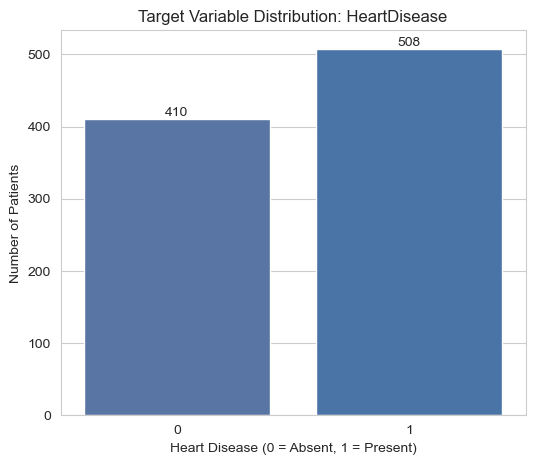

In [159]:
plt.figure(figsize=(6, 5))

ax = sns.countplot(data=df, x='HeartDisease',hue=df['HeartDisease'], legend=False, palette=['#4C72B0', '#3C72B5'])

plt.title('Target Variable Distribution: HeartDisease')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Number of Patients')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

**Interpretation**: The target variable is relatively balanced, with *508 patients (55.3%)* having heart disease and *410 patients (44.7%)* not having heart disease. 
The difference between the two classes is not substantial, so severe class imbalance is not a major concern at this stage.

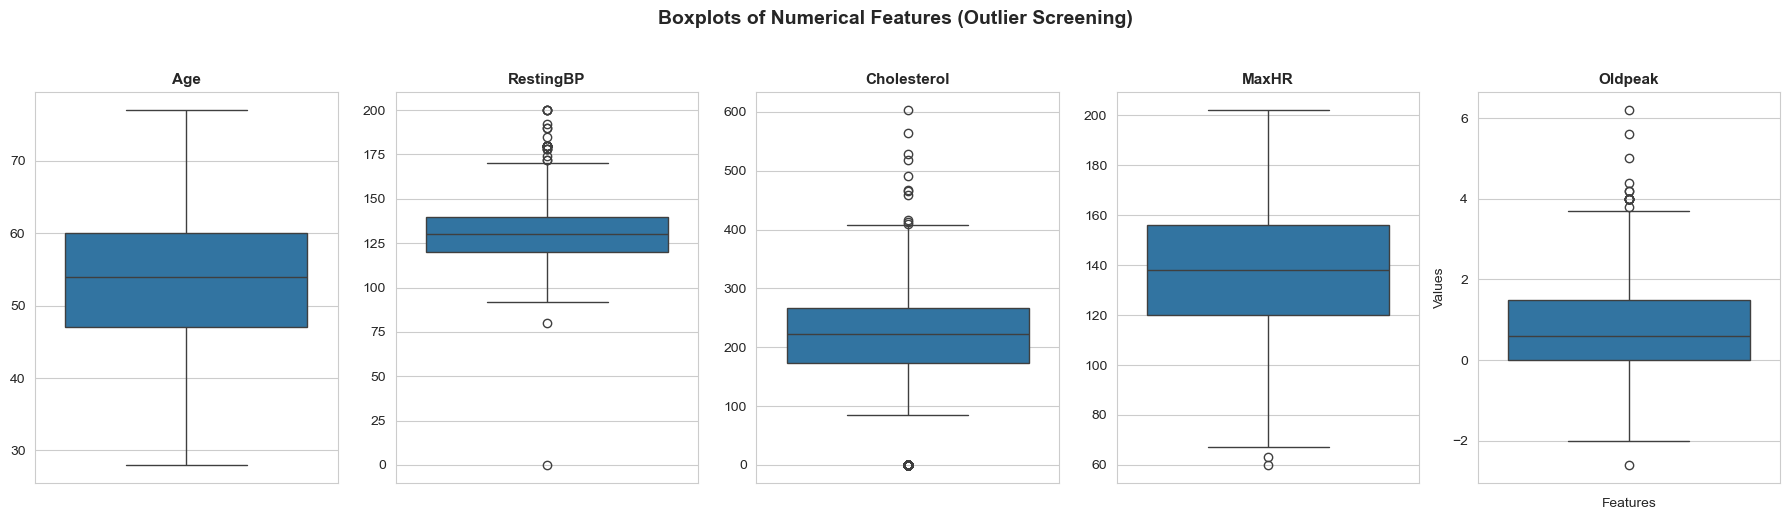

In [161]:
# Numerical features for outlier detection
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')
plt.xlabel('Features')
plt.ylabel('Values')
plt.suptitle('Boxplots of Numerical Features (Outlier Screening)', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

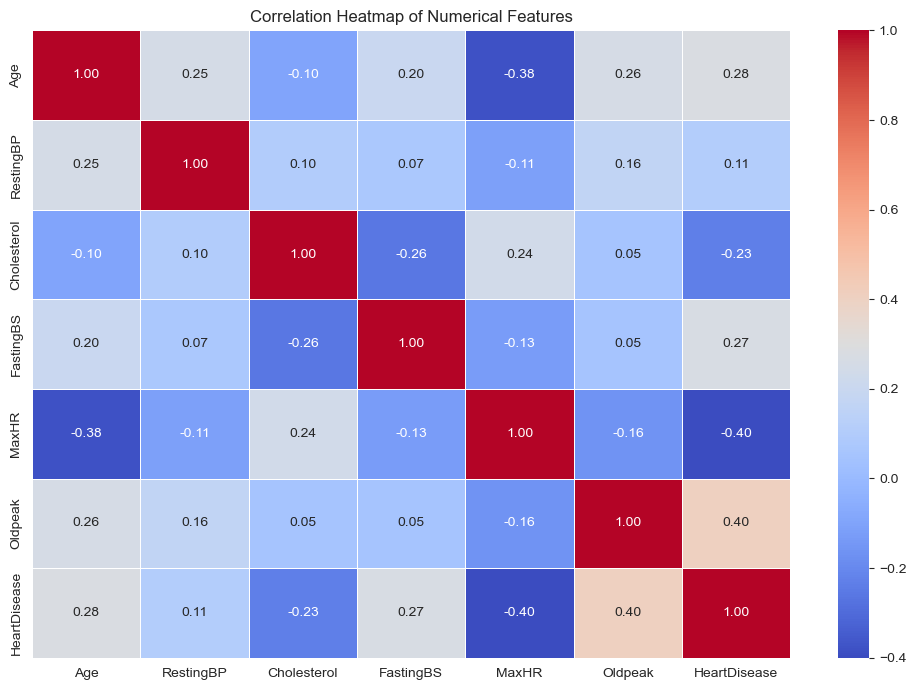

In [162]:
numeric_cols = df[
    ['Age', 'RestingBP', 'Cholesterol', 'FastingBS',
     'MaxHR', 'Oldpeak', 'HeartDisease']
]


correlation_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

**Interpretation**: The heatmap shows that *Oldpeak (0.40)* and *MaxHR (-0.40)* have the strongest linear relationships with HeartDisease among the numerical variables. *Age (0.28)* and *FastingBS (0.27)* show weaker positive relationships, while *Cholesterol (-0.23)* has a weak negative relationship.  The correlations between predictor variables are generally moderate or weak, suggesting no immediate evidence of severe multicollinearity.
However, correlation alone will not determine feature importance, so these relationships will be considered alongside other analyses during feature selection.

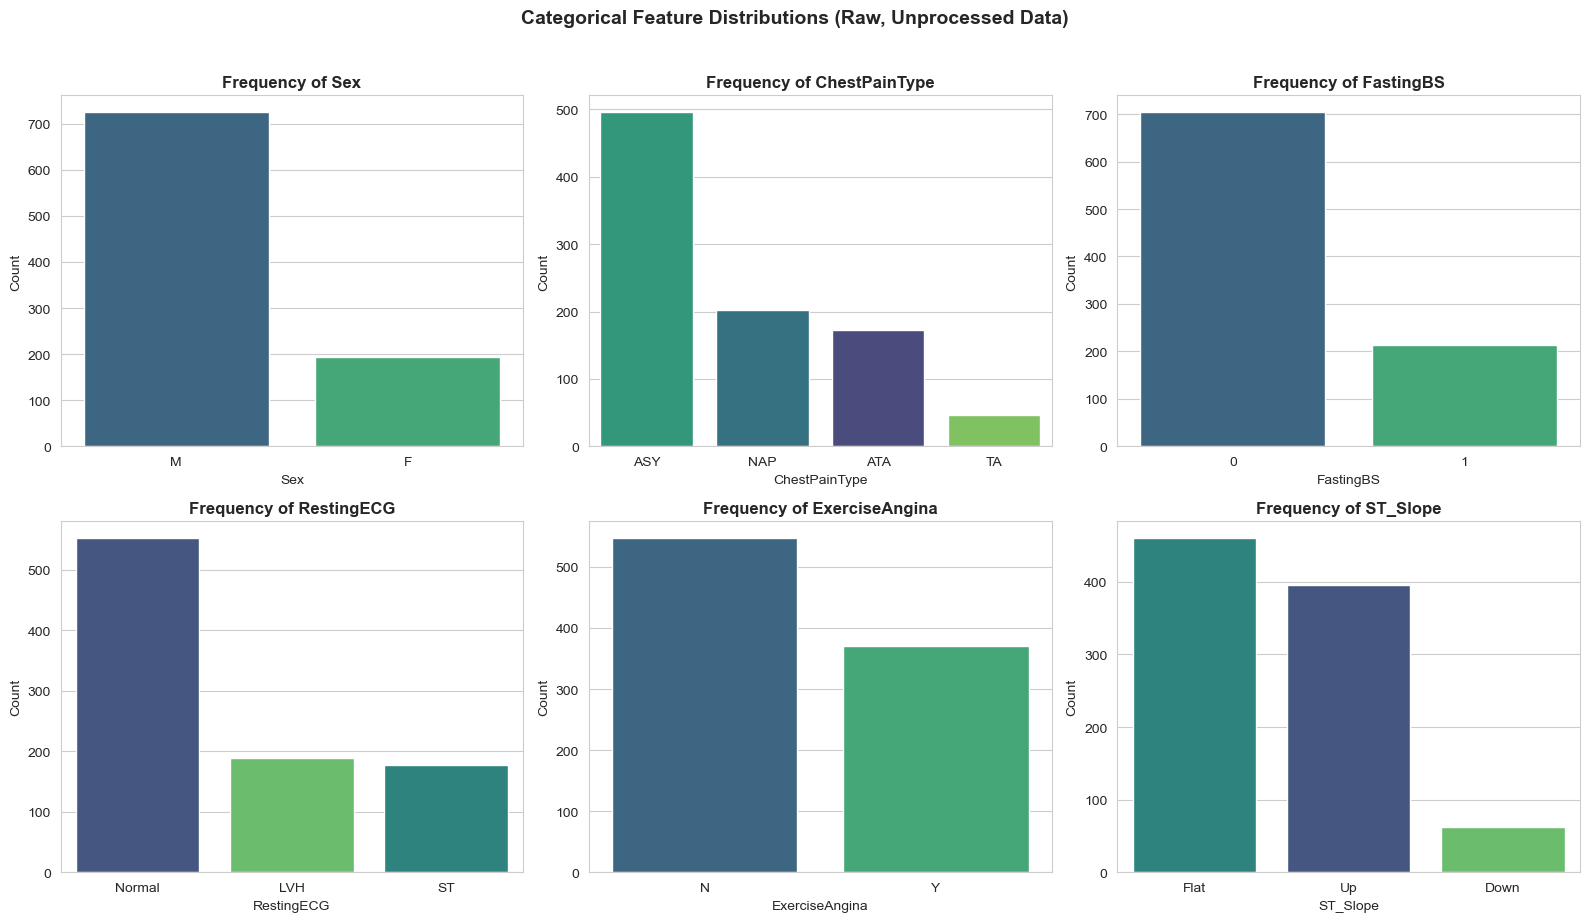

In [164]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(x=df[col], order=order, ax=axes[i], hue=df[col], legend=False, palette='viridis')
    axes[i].set_title(f'Frequency of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions (Raw, Unprocessed Data)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**1.Sex**
The dataset contains approximately 725 males and 193 females, making it predominantly male.
This shows the dataset's composition but does not indicate that males are more likely to have heart disease.
Sex is categorical and will require encoding.

**2. ChestPainType**
ASY (Asymptomatic) is the most common category, followed by NAP, ATA, and TA.
The categories represent different types of chest symptoms, ranging from no reported symptoms to typical angina.
The uneven distribution will be considered during preprocessing.

**3.FastingBS**
Approximately 710 patients have FastingBS = 0, while about 210 have FastingBS = 1.
0 represents fasting blood sugar ≤120 mg/dL, while 1 represents >120 mg/dL.
Most patients therefore fall below the dataset's threshold.

**4.RestingECG**
Normal is the most common result, followed by LVH and ST-T wave abnormality.
The variable describes the patient's heart electrical activity while resting.
All three categories will be retained and encoded.

**5.ExerciseAngina**
Around 550 patients reported no exercise-induced angina, compared with approximately 370 who did.
The feature indicates whether exercise caused chest discomfort related to reduced blood flow to the heart.
It will be retained for further analysis.

**6. ST_Slope**
Flat is the most common category, followed by Up, while Down is least common.
ST_Slope describes the direction of the ST segment during exercise.
Although the categories are unevenly distributed, all will be retained for further analysis.

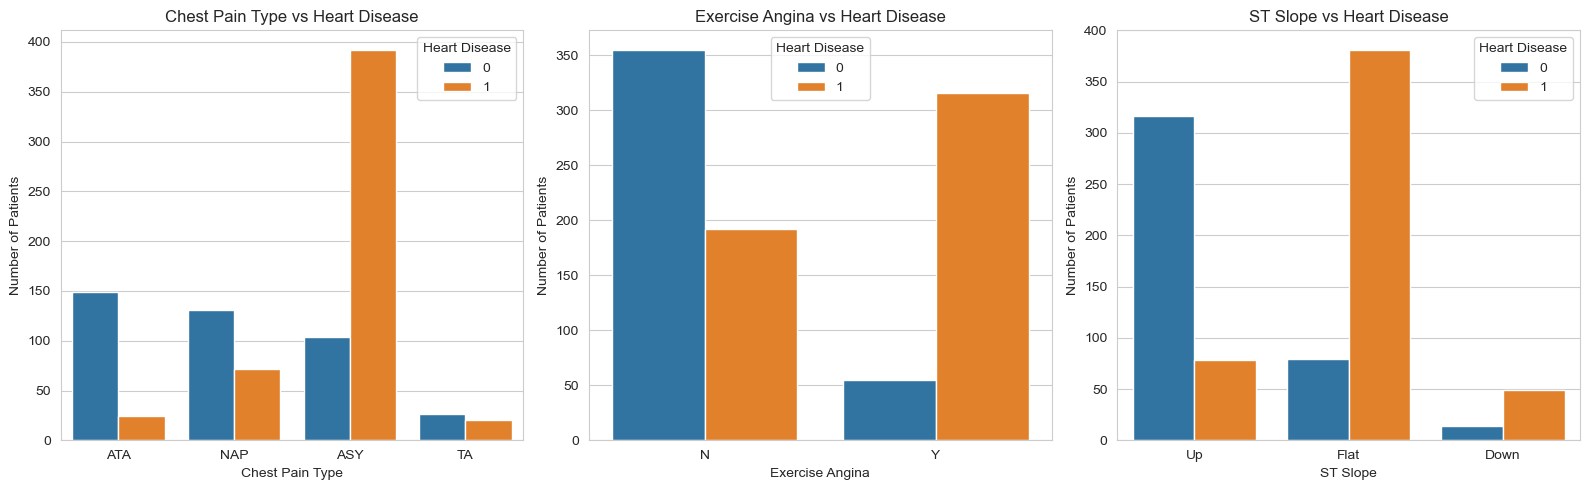

In [166]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chest Pain Type vs Heart Disease
sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', ax=axes[0])
axes[0].set_title('Chest Pain Type vs Heart Disease')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Number of Patients')
axes[0].legend(title='Heart Disease')

# Exercise Angina vs Heart Disease
sns.countplot(data=df, x='ExerciseAngina', hue='HeartDisease', ax=axes[1])
axes[1].set_title('Exercise Angina vs Heart Disease')
axes[1].set_xlabel('Exercise Angina')
axes[1].set_ylabel('Number of Patients')
axes[1].legend(title='Heart Disease')

# ST Slope vs Heart Disease
sns.countplot(data=df, x='ST_Slope', hue='HeartDisease', ax=axes[2])
axes[2].set_title('ST Slope vs Heart Disease')
axes[2].set_xlabel('ST Slope')
axes[2].set_ylabel('Number of Patients')
axes[2].legend(title='Heart Disease')

plt.tight_layout()
plt.show()

* **`ChestPainType`**: Heart disease prevalence varies considerably across categories. **ASY** (*asymptomatic*) displays the highest disease rate at **79.0%**, whereas **ATA** (*atypical angina*) exhibits the lowest at **13.9%** (with **NAP** at **35.5%** and **TA** at **43.5%**). This high variation confirms that `ChestPainType` carries strong signal for separating positive and negative cases.

* **`ExerciseAngina`**: Patients presenting with exercise-induced angina (**Y**) show a substantially elevated heart disease prevalence of **85.2%**, compared to **35.1%** for those without (**N**). This indicates a powerful positive association between exercise angina and the target variable.

* **`ST_Slope`**: Target distribution differs sharply depending on the ST segment slope. The **Flat** category exhibits an **82.8%** disease rate, followed by **Down** at **77.8%**, while **Up** shows a significantly lower prevalence of **19.7%** (an **80.3%** *normal* rate). This identifies 


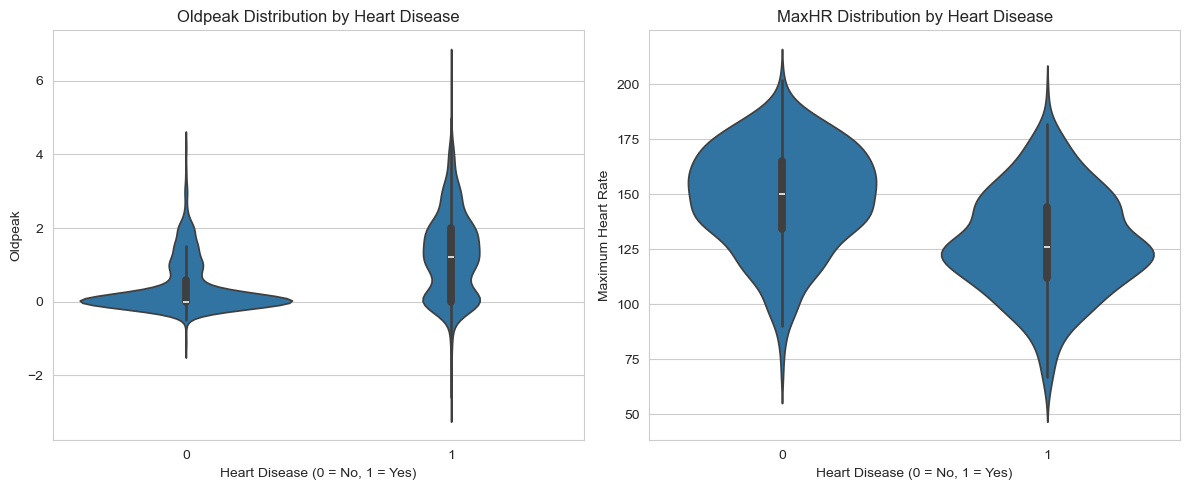

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Oldpeak
sns.violinplot(data=df, x='HeartDisease', y='Oldpeak', ax=axes[0])
axes[0].set_title('Oldpeak Distribution by Heart Disease')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Oldpeak')

# MaxHR
sns.violinplot(data=df, x='HeartDisease', y='MaxHR', ax=axes[1])
axes[1].set_title('MaxHR Distribution by Heart Disease')
axes[1].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[1].set_ylabel('Maximum Heart Rate')

plt.tight_layout()
plt.show()

**Oldpeak**: Patients without heart disease generally have Oldpeak values concentrated around 0, with a relatively narrow distribution. In contrast, patients with heart disease show higher and more widely spread values. This supports the earlier correlation result (r ≈ 0.40) and suggests that higher Oldpeak values are associated with heart disease in this dataset. The presence of negative and extreme values also indicates that Oldpeak should be reviewed during outlier analysis rather than automatically treated as an error.

**MaxHR**: Patients without heart disease generally have higher maximum heart-rate values, with the distribution concentrated around approximately *140–165 bpm.* Patients with heart disease tend to have lower MaxHR values, with much of the distribution around *110–145 bpm*. This agrees with the negative correlation between MaxHR and HeartDisease (r ≈ -0.40), suggesting that lower maximum heart rate is associated with heart disease in this dataset.

# 4.FEATURE ENGINEERING

This section continues directly from the Data Inspection and EDA stage. Using the confirmed findings — no missing values (aside from the disguised zeros identified in `RestingBP`/`Cholesterol`), a reasonably balanced target, and clear categorical–target associations for `ChestPainType`, `ExerciseAngina`, and `ST_Slope` — we now assess whether new features are needed, whether any existing feature is irrelevant, and whether column names require adjustment, before moving into outlier treatment, encoding, and 

**Decision: no new engineered features will be created.**

The dataset's existing 11 predictor variables are already direct, clinically meaningful measurements (e.g. `Age`, `RestingBP`, `Cholesterol`, `MaxHR`) or well-defined categorical clinical assessments (e.g. `ChestPainType`, `ExerciseAngina`, `ST_Slope`). The EDA stage already demonstrated that several of these variables carry strong, independently interpretable signal with respect to `HeartDisease` (e.g. `ChestPainType` prevalence ranging from 13.9% to 79.0% across categories; `ExerciseAngina` at 85.2% vs 35.1%; `ST_Slope` at 82.8%/77.8%/19.7%).

What *will* happen in this section is **transformation of existing features into machine-learning-appropriate representations  through encoding and scaling**  — this is representation engineering, not new feature creation, and is documented separately in those sections.


**4.1 Irrelevant feature assesment**

In [203]:
print("Correlation of numerical predictors with HeartDisease (from EDA):")
num_corr = df[numerical_cols + ['FastingBS', 'HeartDisease']].corr()['HeartDisease'].drop('HeartDisease').sort_values(key=abs, ascending=False)
print(num_corr)
print()
print("Categorical predictors' association with HeartDisease was already established in the EDA stage:")
print("- ChestPainType: heart disease rate ranges from 13.9% (ATA) to 79.0% (ASY)")
print("- ExerciseAngina: 85.2% (Y) vs 35.1% (N)")
print("- ST_Slope: 82.8% (Flat), 77.8% (Down), 19.7% (Up)")

Correlation of numerical predictors with HeartDisease (from EDA):
Oldpeak        0.403951
MaxHR         -0.400421
Age            0.282039
FastingBS      0.267291
Cholesterol   -0.232741
RestingBP      0.107589
Name: HeartDisease, dtype: float64

Categorical predictors' association with HeartDisease was already established in the EDA stage:
- ChestPainType: heart disease rate ranges from 13.9% (ATA) to 79.0% (ASY)
- ExerciseAngina: 85.2% (Y) vs 35.1% (N)
- ST_Slope: 82.8% (Flat), 77.8% (Down), 19.7% (Up)


**Interpretation:** No predictor variable shows zero or near-zero association with `HeartDisease`. Even the weakest numerical correlate, `RestingBP` (r ≈ +0.11), is not zero, and weak individual correlation alone is not sufficient grounds for removal per the assignment guardrails — a variable can still contribute jointly with other features even if its individual linear correlation is modest. 

**Conclusion: no irrelevant features were identified. All 11 original predictor variables are retained for the preprocessing pipeline.**


**4.2 Column renaming**

In [207]:
print("Current column names:")
for c in df.columns:
    print(f"  '{c}'  (has whitespace: {c != c.strip()})")


Current column names:
  'Age'  (has whitespace: False)
  'Sex'  (has whitespace: False)
  'ChestPainType'  (has whitespace: False)
  'RestingBP'  (has whitespace: False)
  'Cholesterol'  (has whitespace: False)
  'FastingBS'  (has whitespace: False)
  'RestingECG'  (has whitespace: False)
  'MaxHR'  (has whitespace: False)
  'ExerciseAngina'  (has whitespace: False)
  'Oldpeak'  (has whitespace: False)
  'ST_Slope'  (has whitespace: False)
  'HeartDisease'  (has whitespace: False)


**Interpretation:** All column names are already consistent, descriptive, and free of whitespace or casing irregularities — 

**Decision: no column renaming is performed.** The original column names are preserved unchanged into the next sections.


# 5. Outlier detection and treatment

**5.1 IQR analysis**

In [213]:
iqr_rows = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_low = (df[col] < lower).sum()
    n_high = (df[col] > upper).sum()
    iqr_rows.append([col, round(Q1,2), round(Q3,2), round(IQR,2),
                      round(lower,2), round(upper,2), n_low, n_high, n_low + n_high])

iqr_summary = pd.DataFrame(iqr_rows, columns=[
    'Feature', 'Q1', 'Q3', 'IQR', 'Lower_Bound', 'Upper_Bound',
    'Low_Outliers', 'High_Outliers', 'Total_Outliers'
])
iqr_summary

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Low_Outliers,High_Outliers,Total_Outliers
0,Age,47.00,60.0,13.00,27.50,79.50,0,0,0
1,RestingBP,120.00,140.0,20.00,90.00,170.00,2,26,28
2,Cholesterol,173.25,267.0,93.75,32.62,407.62,172,11,183
3,MaxHR,120.00,156.0,36.00,66.00,210.00,2,0,2
4,Oldpeak,0.00,1.5,1.50,-2.25,3.75,1,15,16


**Interpretation of the IQR table:**
- **Age:** 0 outliers — the full age range (28–77) sits comfortably within the IQR bounds.
- **RestingBP:** 28 total outliers (2 low, 26 high). The 2 low values include the `RestingBP = 0` record already flagged, plus one legitimate low reading of 80 mmHg (still a plausible, if low, resting blood pressure). The 26 high values are within a clinically plausible hypertensive range.
- **Cholesterol:** 183 total outliers (172 low, 11 high). The 172 low outliers correspond almost exactly to the 172 zero-value records already identified as disguised missing data. The 11 high outliers are elevated but clinically plausible cholesterol readings.
- **MaxHR:** 2 low outliers — both are plausible low heart-rate readings, not invalid values.
- **Oldpeak:** 16 total outliers (1 low, 15 high). The single low outlier is the -2.6 minimum; the 15 high outliers are elevated ST-depression readings consistent with the EDA finding that Oldpeak is higher and more spread out among heart-disease-positive patients.

We now reason through each of these cases individually below, rather than removing all 229 flagged values indiscriminately.


In [216]:
print("Dataset shape BEFORE outlier treatment:", df.shape)

#new dataset copy
df_clean = df.copy()

# Step 1: convert clinically invalid zero readings to NaN for RestingBP and Cholestrol
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, np.nan)
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, np.nan)

print()
print("Missing values created by flagging invalid zeros as NaN:")
print(df_clean[['RestingBP', 'Cholesterol']].isnull().sum())

# Step 2: impute using the median of the remaining valid readings
restingbp_median = df_clean['RestingBP'].median()
cholesterol_median = df_clean['Cholesterol'].median()
print()
print(f"RestingBP median (valid readings only): {restingbp_median}")
print(f"Cholesterol median (valid readings only): {cholesterol_median}")

df_clean['RestingBP'] = df_clean['RestingBP'].fillna(restingbp_median)
df_clean['Cholesterol'] = df_clean['Cholesterol'].fillna(cholesterol_median)

print()
print("Missing values remaining after imputation:", df_clean[['RestingBP', 'Cholesterol']].isnull().sum().sum())
print("Dataset shape AFTER outlier treatment:", df_clean.shape)


Dataset shape BEFORE outlier treatment: (918, 12)

Missing values created by flagging invalid zeros as NaN:
RestingBP        1
Cholesterol    172
dtype: int64

RestingBP median (valid readings only): 130.0
Cholesterol median (valid readings only): 237.0

Missing values remaining after imputation: 0
Dataset shape AFTER outlier treatment: (918, 12)


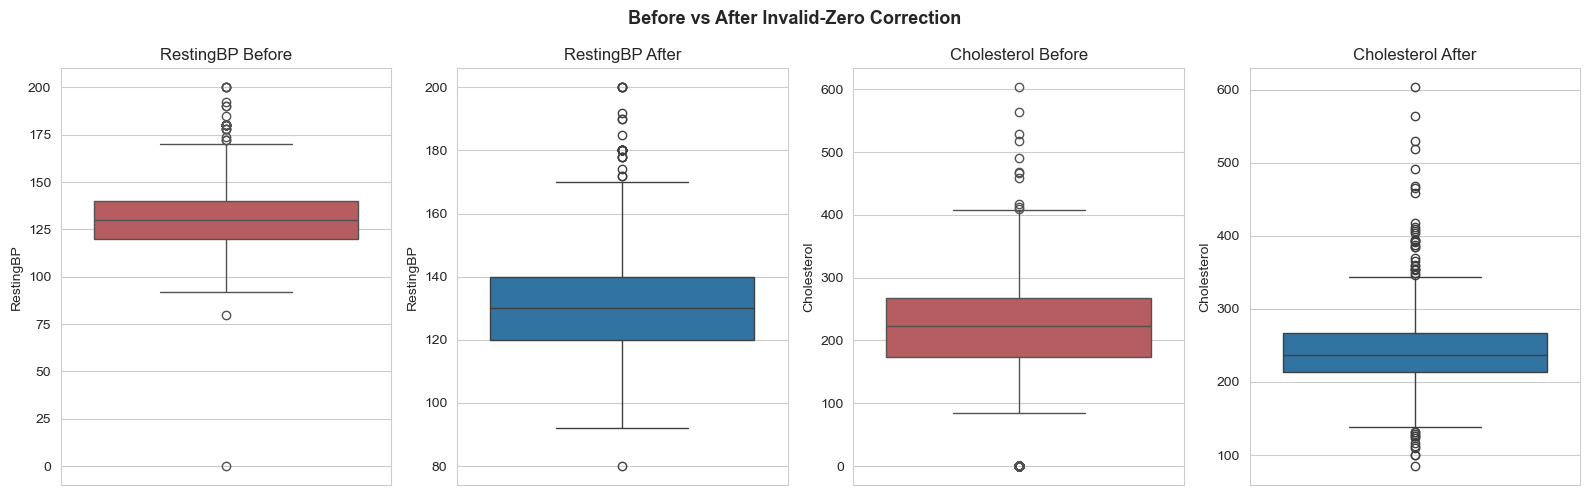

In [220]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# RestingBP - Before
sns.boxplot(y=df['RestingBP'], ax=axes[0],color='#C44E52')
axes[0].set_title('RestingBP Before')

# RestingBP - After
sns.boxplot(y=df_clean['RestingBP'], ax=axes[1])
axes[1].set_title('RestingBP After')

# Cholesterol - Before
sns.boxplot(y=df['Cholesterol'], ax=axes[2],color='#C44E52')
axes[2].set_title('Cholesterol Before')

# Cholesterol - After
sns.boxplot(y=df_clean['Cholesterol'], ax=axes[3])
axes[3].set_title('Cholesterol After')

plt.suptitle(
    'Before vs After Invalid-Zero Correction',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Interpretation:** After treatment, the **minimum of `RestingBP` rises from 0 to 80** and the **minimum of `Cholesterol` rises from 0 to a plausible physiological value**, while the count of valid observations remains at 918 for both. The means shift modestly (e.g. `Cholesterol`'s mean increases, since the zero values were previously dragging it down artificially). This confirms the invalid low-end cluster has been corrected without discarding any patient records or altering the plausible high-end extreme values that were deliberately retained.


# 6. Feature Encoding

**6.1  Binary encoding for Categorical variables sex(M/F) and ExerciseAngina(Y/N)**

In [226]:
df_encoded = df_clean.copy()

# Binary encoding: map to 0/1
df_encoded['Sex'] = df_encoded['Sex'].map({'M': 1, 'F': 0})
df_encoded['ExerciseAngina'] = df_encoded['ExerciseAngina'].map({'Y': 1, 'N': 0})

print("Sex encoded -> unique values:", sorted(df_encoded['Sex'].unique()), " (1 = Male, 0 = Female)")
print("ExerciseAngina encoded -> unique values:", sorted(df_encoded['ExerciseAngina'].unique()), " (1 = Yes, 0 = No)")
print("FastingBS already binary -> unique values:", sorted(df_encoded['FastingBS'].unique()))


Sex encoded -> unique values: [0, 1]  (1 = Male, 0 = Female)
ExerciseAngina encoded -> unique values: [0, 1]  (1 = Yes, 0 = No)
FastingBS already binary -> unique values: [0, 1]


**6.2   One-Hot Encoding**

`ChestPainType`, `RestingECG`, and `ST_Slope` are **nominal** categorical variables — their categories have no inherent order (e.g. `ASY`, `NAP`, `ATA`, `TA` are different symptom types, not points on a scale). Using ordinary Label Encoding here (e.g. `ASY=1, NAP=2, ATA=3, TA=4`) would incorrectly imply that `TA > ATA > NAP > ASY`, a false numerical ranking that has no clinical basis and could mislead distance-based or linear models. One-Hot Encoding avoids this by creating a separate binary indicator column per category, with no implied ordering.


In [231]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['ChestPainType', 'RestingECG', 'ST_Slope'],
    drop_first=True
)

# Convert the resulting boolean dummy columns to integer 0/1 for consistency
bool_cols = df_encoded.select_dtypes(include='bool').columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("New one-hot encoded columns created:")
print(bool_cols)

New one-hot encoded columns created:
['ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


In [235]:
df_encoded.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,0,1,0,1,0,0,1


**Interpretation:** Encoding expanded the dataset from 12 to **16 columns** — the original 5 numerical columns and target are unchanged, `Sex`/`ExerciseAngina`/`FastingBS` are now clean binary 0/1 columns, and the three nominal categorical variables were replaced by 7 one-hot dummy columns (`ChestPainType` → 3 dummies, `RestingECG` → 2 dummies, `ST_Slope` → 2 dummies, each with one reference category dropped). `HeartDisease` remains a single binary column (values 0/1) as required 


# 7.Feature Scaling

The five numerical predictors (`Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`) operate on very different measurement scales — for example `Oldpeak` ranges roughly 0–6 while `Cholesterol` ranges into the hundreds. Left unscaled, this would let large-magnitude variables dominate distance-based or gradient-based algorithms regardless of their actual predictive value.

In [243]:
#choice -StandardScaler 
from sklearn.preprocessing import StandardScaler

df_scaled = df_encoded.copy()
scaler = StandardScaler()

df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("Numerical columns scaled:", numerical_cols)
print("Scaler used: StandardScaler (mean=0, std=1)")


Numerical columns scaled: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Scaler used: StandardScaler (mean=0, std=1)


In [245]:
scale_comparison = pd.DataFrame({
    'mean_before': df_encoded[numerical_cols].mean(),
    'std_before': df_encoded[numerical_cols].std(),
    'mean_after': df_scaled[numerical_cols].mean(),
    'std_after': df_scaled[numerical_cols].std()
}).round(4)
scale_comparison

,mean_before,std_before,mean_after,std_after
Age,53.5109,9.4326,-0.0,1.0005
RestingBP,132.5381,17.9901,0.0,1.0005
Cholesterol,243.2048,53.4013,0.0,1.0005
MaxHR,136.8094,25.4603,0.0,1.0005
Oldpeak,0.8874,1.0666,0.0,1.0005


**Intepretation**
Numerical continuous features, including `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, and `Oldpeak`, were standardized using *StandardScaler* to place them on a comparable scale while preserving their relative distributions. The binary `FastingBS`,`HeartDisease` variable and `encoded categorical indicators` were not scaled.

# 8. Feature selection

**8.1 Correlation Analysis**

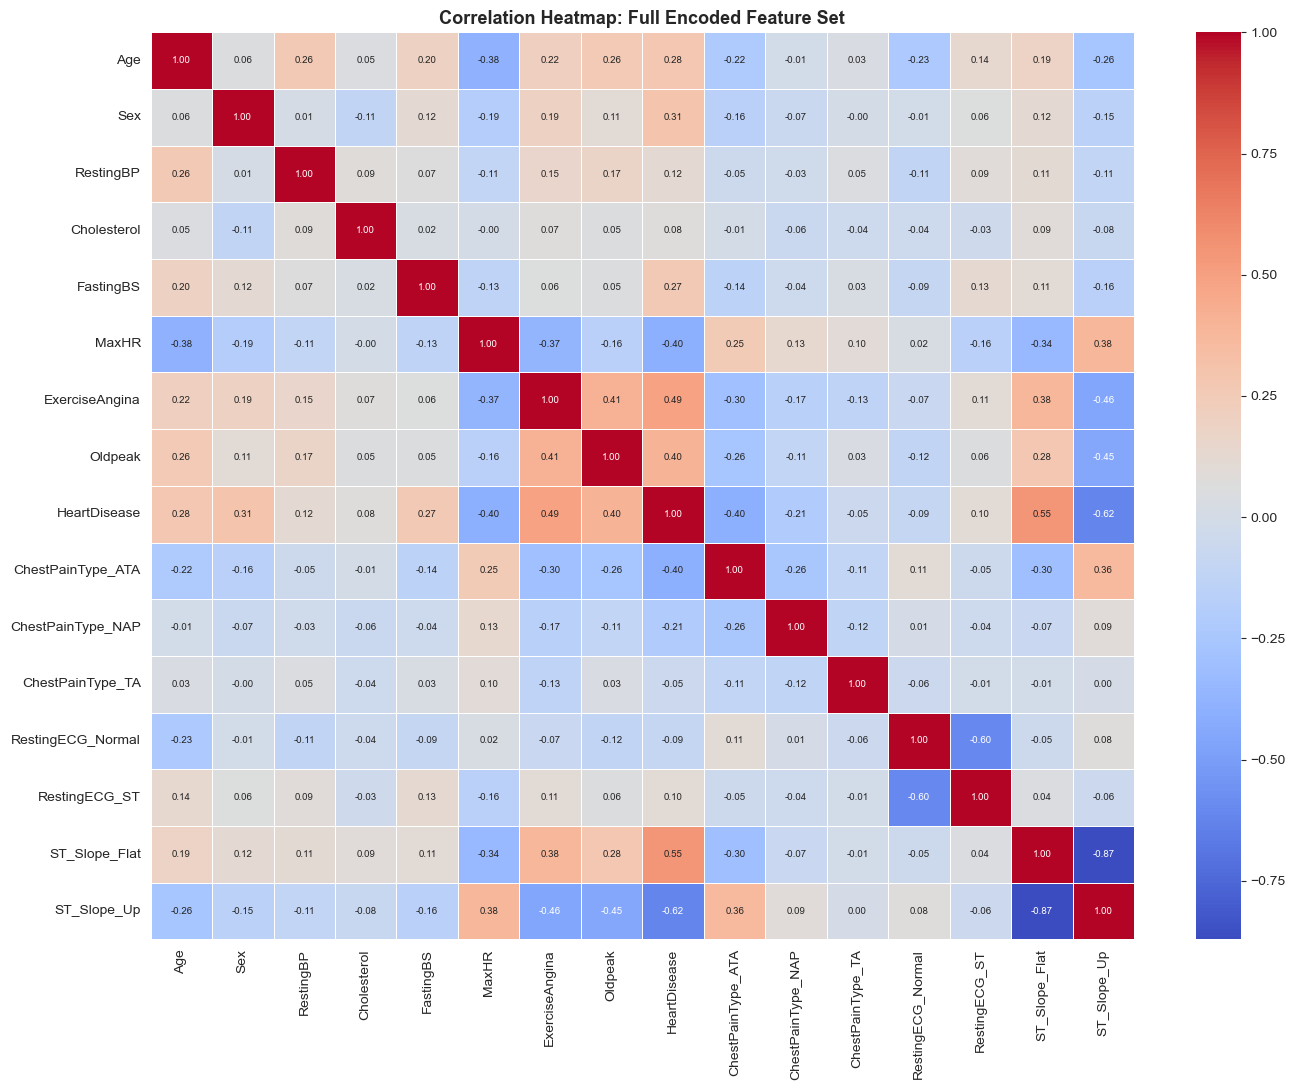

In [255]:
#using a heatmap to visualise target relationships 
plt.figure(figsize=(14, 11))
full_corr = df_scaled.corr()
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.4,
            annot_kws={'size': 7})
plt.title('Correlation Heatmap: Full Encoded Feature Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [257]:
# Correlation of numerical features with the target
target_corr = df_scaled.corr()['HeartDisease'].drop('HeartDisease')
target_corr.sort_values(key=abs, ascending=False).round(3)

ST_Slope_Up         -0.622
ST_Slope_Flat        0.554
ExerciseAngina       0.494
Oldpeak              0.404
ChestPainType_ATA   -0.402
MaxHR               -0.400
Sex                  0.305
Age                  0.282
FastingBS            0.267
ChestPainType_NAP   -0.213
RestingBP            0.118
RestingECG_ST        0.103
RestingECG_Normal   -0.092
Cholesterol          0.076
ChestPainType_TA    -0.055
Name: HeartDisease, dtype: float64

In [261]:
numeric_cols = df_clean.select_dtypes(include='number').columns

corr = df_clean[numeric_cols].corr()

corr['HeartDisease'].drop('HeartDisease').sort_values(
    key=abs, ascending=False
).round(3)

Oldpeak        0.404
MaxHR         -0.400
Age            0.282
FastingBS      0.267
RestingBP      0.118
Cholesterol    0.076
Name: HeartDisease, dtype: float64

**Intepretation:**
`ST_Slope_Up` *(r ≈ -0.62)* and `ST_Slope_Flat` *(r ≈ +0.55)* show the strongest correlations with HeartDisease among the encoded categorical features. 
This is consistent with the earlier analysis(with df clean ), where `ST_Slope `showed substantial differences in heart disease prevalence across its categories. 
`Oldpeak` and `MaxHR` also retain their moderate relationships with the target, with correlations of approximately *+0.40 and -0.40*, respectively.




**8.2 Feature Importance**

In [267]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split features (X) and target (y) 
X = df_scaled.drop(columns=['HeartDisease'])
y = df_scaled['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42)
rf_baseline.fit(X_train, y_train)

print(f"Baseline Random Forest — train accuracy: {rf_baseline.score(X_train, y_train):.3f}")
print(f"Baseline Random Forest — test accuracy:  {rf_baseline.score(X_test, y_test):.3f}")


Baseline Random Forest — train accuracy: 1.000
Baseline Random Forest — test accuracy:  0.875


**Interpretation**
: The preliminary Random Forest achieved *100% training accuracy*and *87.5% test accuracy*. The strong test performance suggests that the available features contain useful information for distinguishing between patients with and without heart disease. However, the difference between training and test accuracy indicates some degree of overfitting. Since this model is being used only to assess feature importance at this stage, these results are not treated as the final model evaluation

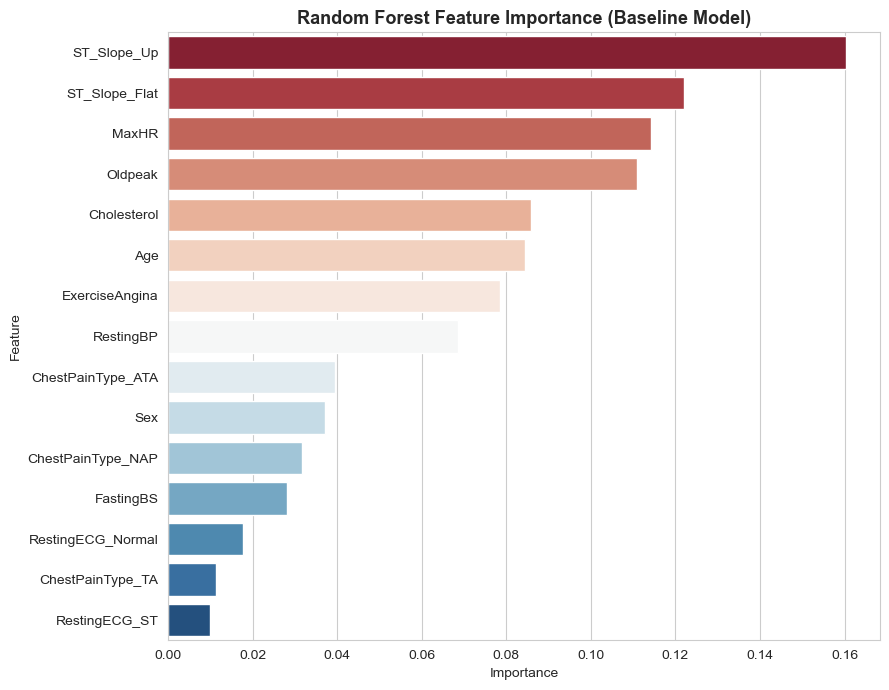

Feature importance ranking:
ST_Slope_Up          0.1604
ST_Slope_Flat        0.1220
MaxHR                0.1143
Oldpeak              0.1109
Cholesterol          0.0858
Age                  0.0843
ExerciseAngina       0.0784
RestingBP            0.0685
ChestPainType_ATA    0.0395
Sex                  0.0371
ChestPainType_NAP    0.0316
FastingBS            0.0281
RestingECG_Normal    0.0178
ChestPainType_TA     0.0114
RestingECG_ST        0.0099
dtype: float64


In [272]:
#showing the numeric values from decision made 
feature_importance = pd.Series(
    rf_baseline.feature_importances_, index=X.columns
).sort_values(ascending=False)

#visualising the results 
plt.figure(figsize=(9, 7))
sns.barplot(x=feature_importance.values, y=feature_importance.index, hue=feature_importance.index,
            legend=False, palette='RdBu')
plt.title('Random Forest Feature Importance (Baseline Model)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importance ranking:")
print(feature_importance.round(4))

**Interpretation**

`ST_Slope_Up (0.1604)` is the most influential feature in the Random Forest, followed by `ST_Slope_Flat (0.1220)`. This reinforces the earlier EDA finding that ST_Slope has a strong relationship with heart disease.

`MaxHR (0.1143)` and `Oldpeak (0.1109)` are also among the most important predictors. This agrees with the earlier analysis showing that both have moderate correlations with HeartDisease.

`Cholesterol (0.0858)`, `Age (0.0843)`, `ExerciseAngina (0.0784)`, and `RestingBP (0.0685)` provide additional predictive information, although their importance is lower.
The encoded chest-pain categories have relatively smaller individual importance values. This does not mean ChestPainType is unimportant overall, because its information is distributed across several encoded columns.

`RestingECG` categories and `ChestPainType_TA` have the lowest individual importance in this Random Forest.

# 9. Dataset Validation 

In [282]:
print("FINAL VALIDATION: heart_disease_ml_ready")
print()
print("Shape:", df_scaled.shape)
print()
print("Column names:")
print(df_scaled.columns.tolist())


FINAL VALIDATION: heart_disease_ml_ready

Shape: (918, 16)

Column names:
['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up']


In [286]:
print(df.dtypes)

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [292]:
print("Missing values per columns:")
print (df_scaled.isna().sum())
print()
print("Duplicated rows:")
print(df_scaled.duplicated().sum())

Missing values per columns:
Age                  0
Sex                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
ExerciseAngina       0
Oldpeak              0
HeartDisease         0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_Normal    0
RestingECG_ST        0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64

Duplicated rows:
0


In [294]:
df_scaled.head(5)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,1,0.415002,0.858035,0,1.382928,0,-0.832432,0,1,0,0,1,0,0,1
1,-0.478484,0,1.527329,-1.184227,0,0.754157,0,0.105664,1,0,1,0,1,0,1,0
2,-1.751359,1,-0.141161,0.745617,0,-1.525138,0,-0.832432,0,1,0,0,0,1,0,1
3,-0.584556,0,0.303769,-0.547191,0,-1.132156,1,0.574711,1,0,0,0,1,0,1,0
4,0.051881,1,0.971166,-0.903182,0,-0.581981,0,-0.832432,0,0,1,0,1,0,0,1
